In [1]:
import pandas as pd
df = pd.read_csv('student_habits_performance.csv')

In [2]:
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [4]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [5]:
print(df.isnull().sum())

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


Since “None” may actually mean unknown (not truly absent), keep it as a category.

In [6]:
df['parental_education_level'] = df['parental_education_level'].fillna('Unknown')

In [7]:
cat_cols =[ 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality','extracurricular_participation']
for col in cat_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts())


gender value counts:
gender
Female    481
Male      477
Other      42
Name: count, dtype: int64

part_time_job value counts:
part_time_job
No     785
Yes    215
Name: count, dtype: int64

diet_quality value counts:
diet_quality
Fair    437
Good    378
Poor    185
Name: count, dtype: int64

parental_education_level value counts:
parental_education_level
High School    392
Bachelor       350
Master         167
Unknown         91
Name: count, dtype: int64

internet_quality value counts:
internet_quality
Good       447
Average    391
Poor       162
Name: count, dtype: int64

extracurricular_participation value counts:
extracurricular_participation
No     682
Yes    318
Name: count, dtype: int64


In [8]:
print(df.isnull().sum())

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
dtype: int64


In [9]:
df.duplicated().sum()

np.int64(0)

No duplicates are there. 

## EDA

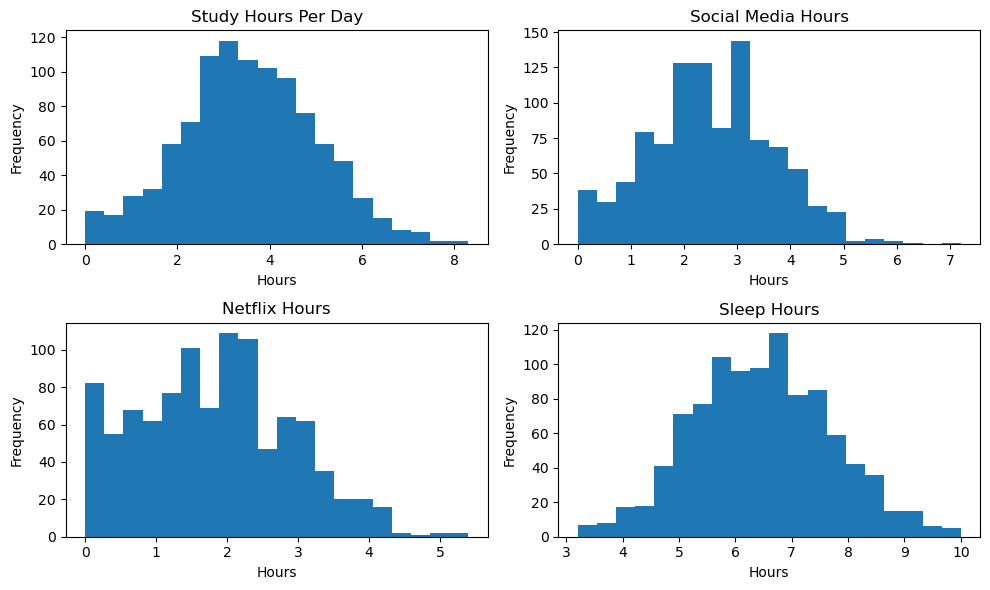

In [10]:
import matplotlib.pyplot as plt

cols = ['study_hours_per_day', 'social_media_hours', 'netflix_hours', 'sleep_hours']

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(f'{col.replace("_", " ").title()}')
    axes[i].set_xlabel('Hours')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

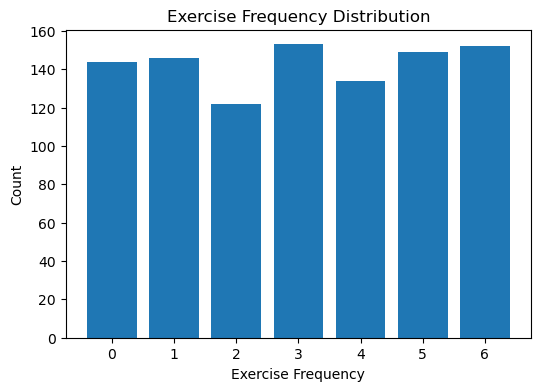

In [11]:
counts = df['exercise_frequency'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)
plt.title('Exercise Frequency Distribution')
plt.xlabel('Exercise Frequency')
plt.ylabel('Count')
plt.grid(False)

plt.show()

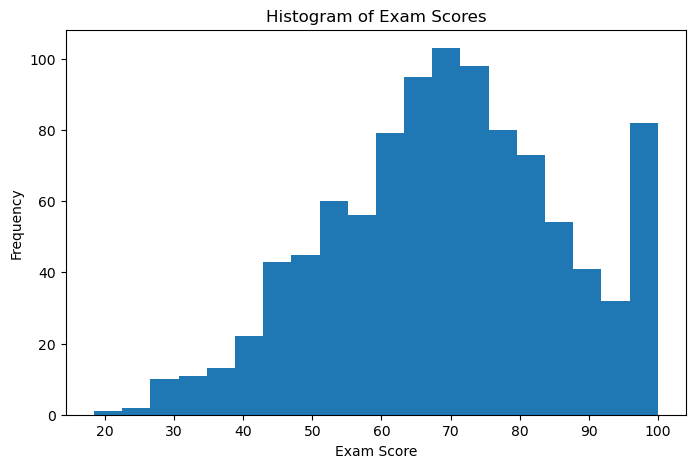

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df['exam_score'], bins=20)

plt.title('Histogram of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')

plt.show()

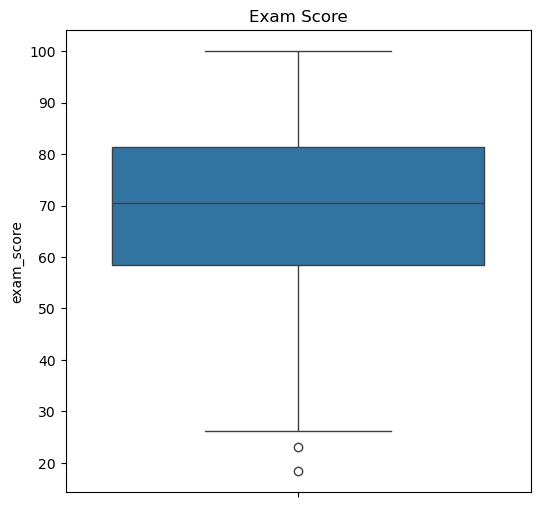

In [16]:
import seaborn as sns
plt.figure(figsize=(6,6))
sns.boxplot(data=df['exam_score'])
plt.title("Exam Score")
plt.show()

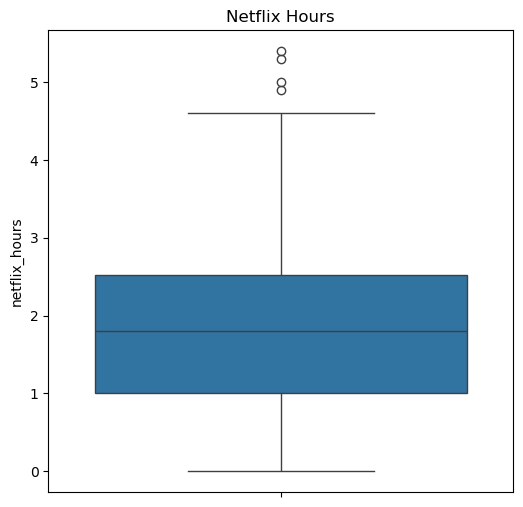

In [17]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['netflix_hours'])
plt.title("Netflix Hours")
plt.show()

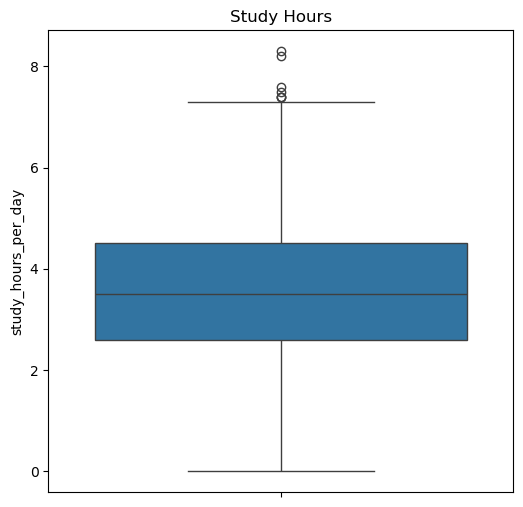

In [18]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['study_hours_per_day'])
plt.title("Study Hours")
plt.show()

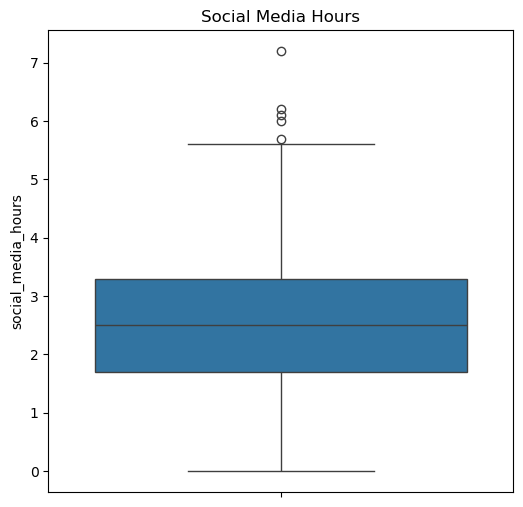

In [19]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['social_media_hours'])
plt.title("Social Media Hours")
plt.show()

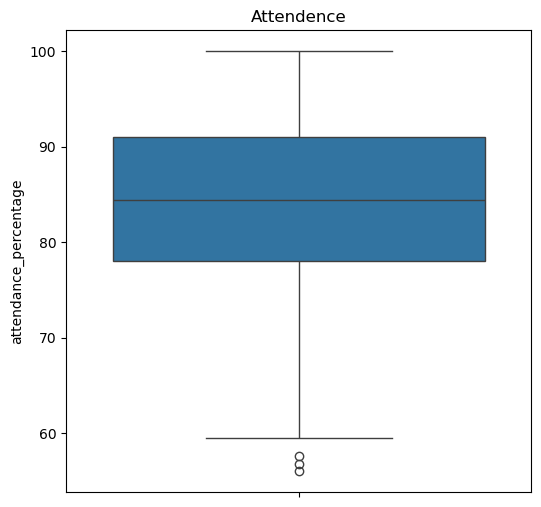

In [20]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['attendance_percentage'])
plt.title("Attendence")
plt.show()

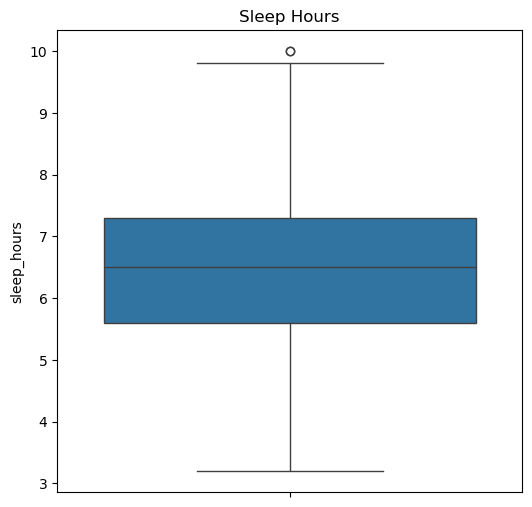

In [21]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['sleep_hours'])
plt.title("Sleep Hours")
plt.show()

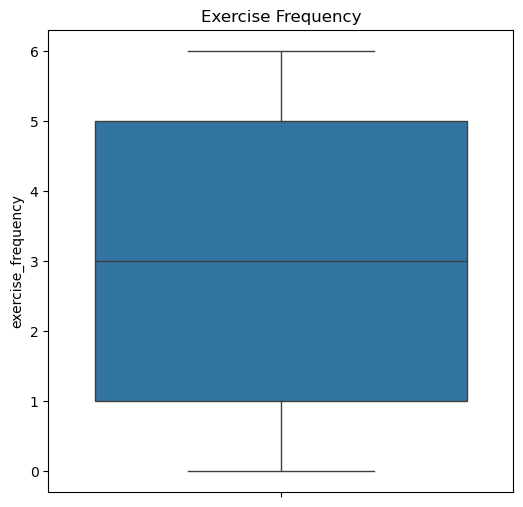

In [22]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['exercise_frequency'])
plt.title("Exercise Frequency")
plt.show()

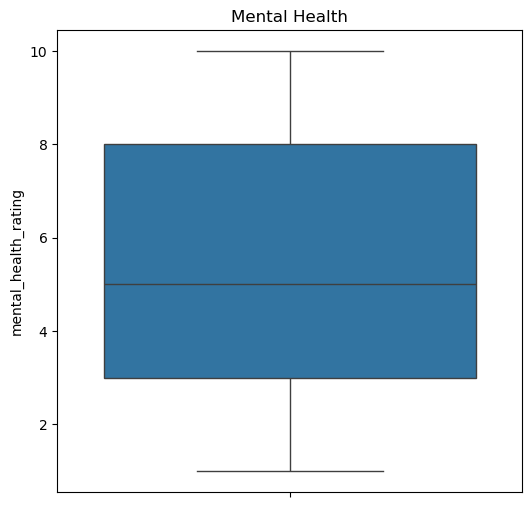

In [23]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['mental_health_rating'])
plt.title("Mental Health")
plt.show()

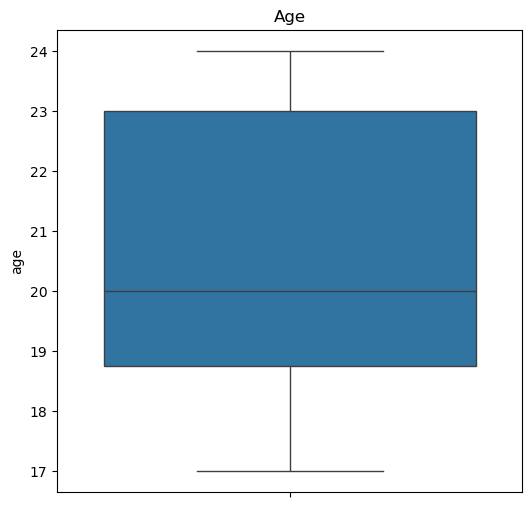

In [25]:
plt.figure(figsize=(6,6))
sns.boxplot(data=df['age'])
plt.title("Age")
plt.show()

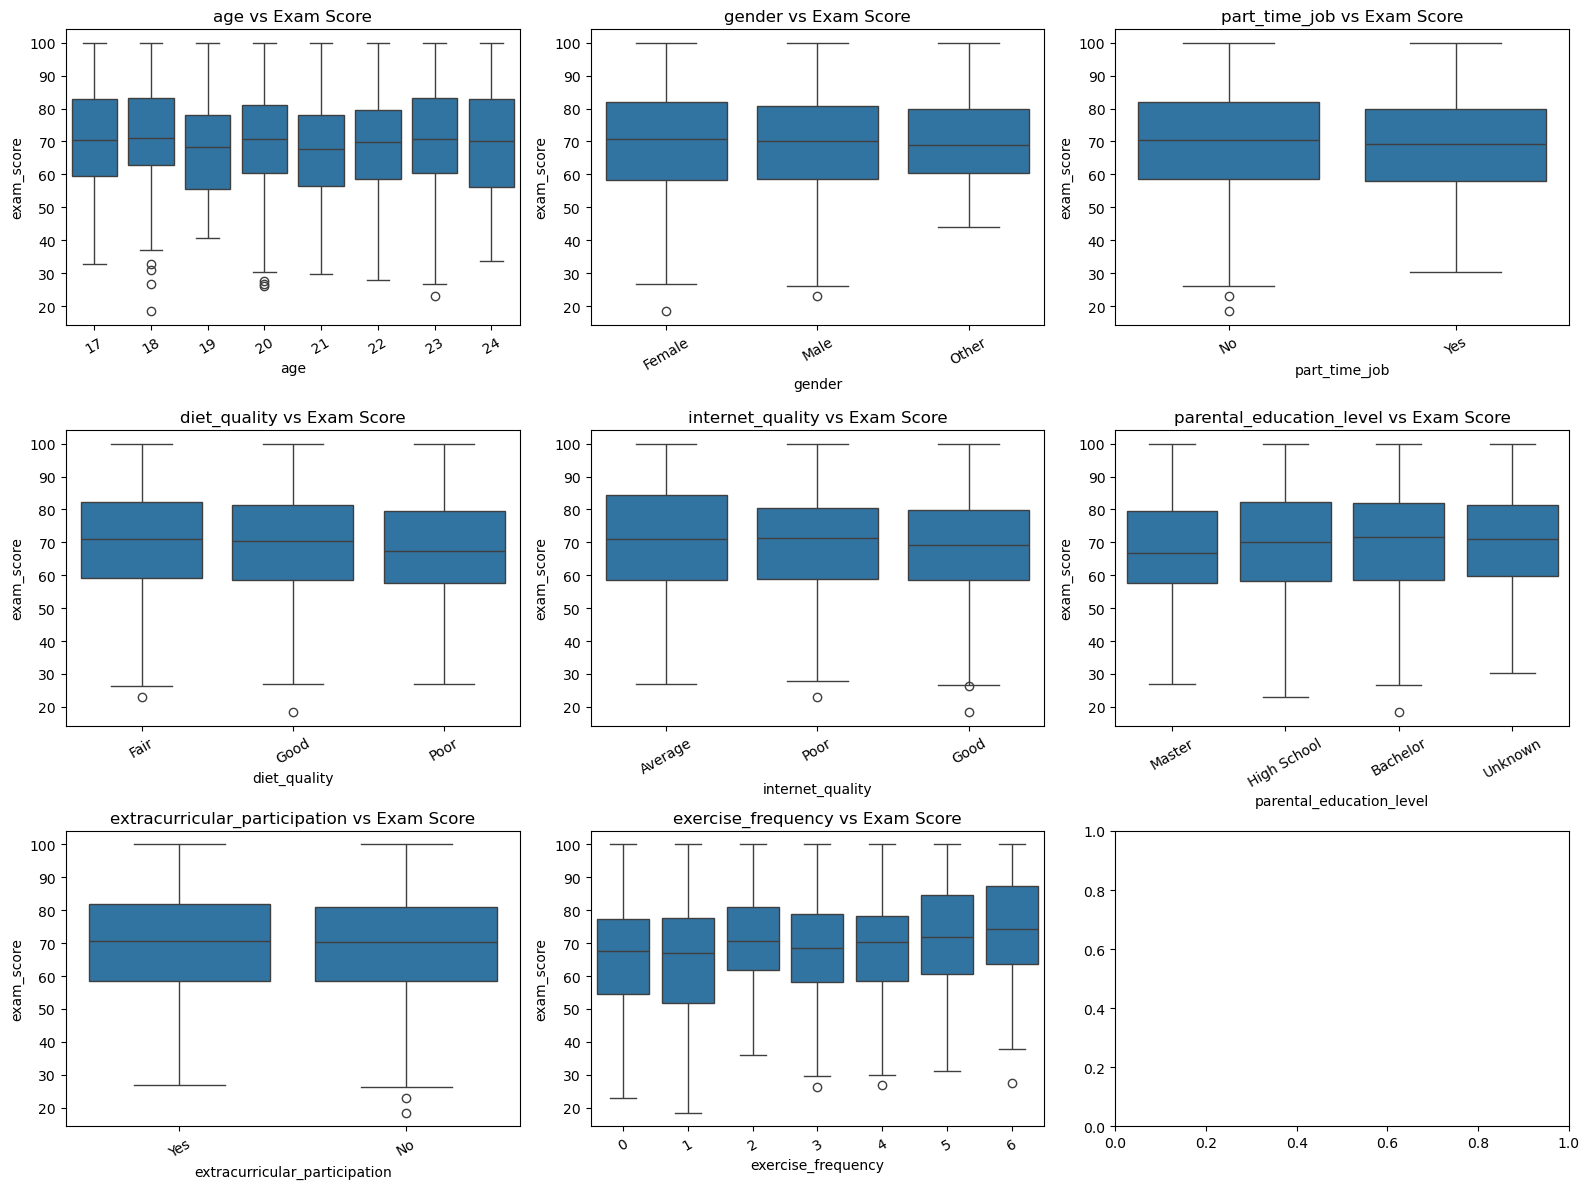

In [26]:
cat_features = ['age',
    'gender',
    'part_time_job',
    'diet_quality',
    'internet_quality',
    'parental_education_level',
    'extracurricular_participation',
    'exercise_frequency'
]

fig, axes = plt.subplots(3, 3, figsize=(16,12))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    sns.boxplot(data=df, x=col, y='exam_score', ax=axes[i])
    axes[i].set_title(f'{col} vs Exam Score')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

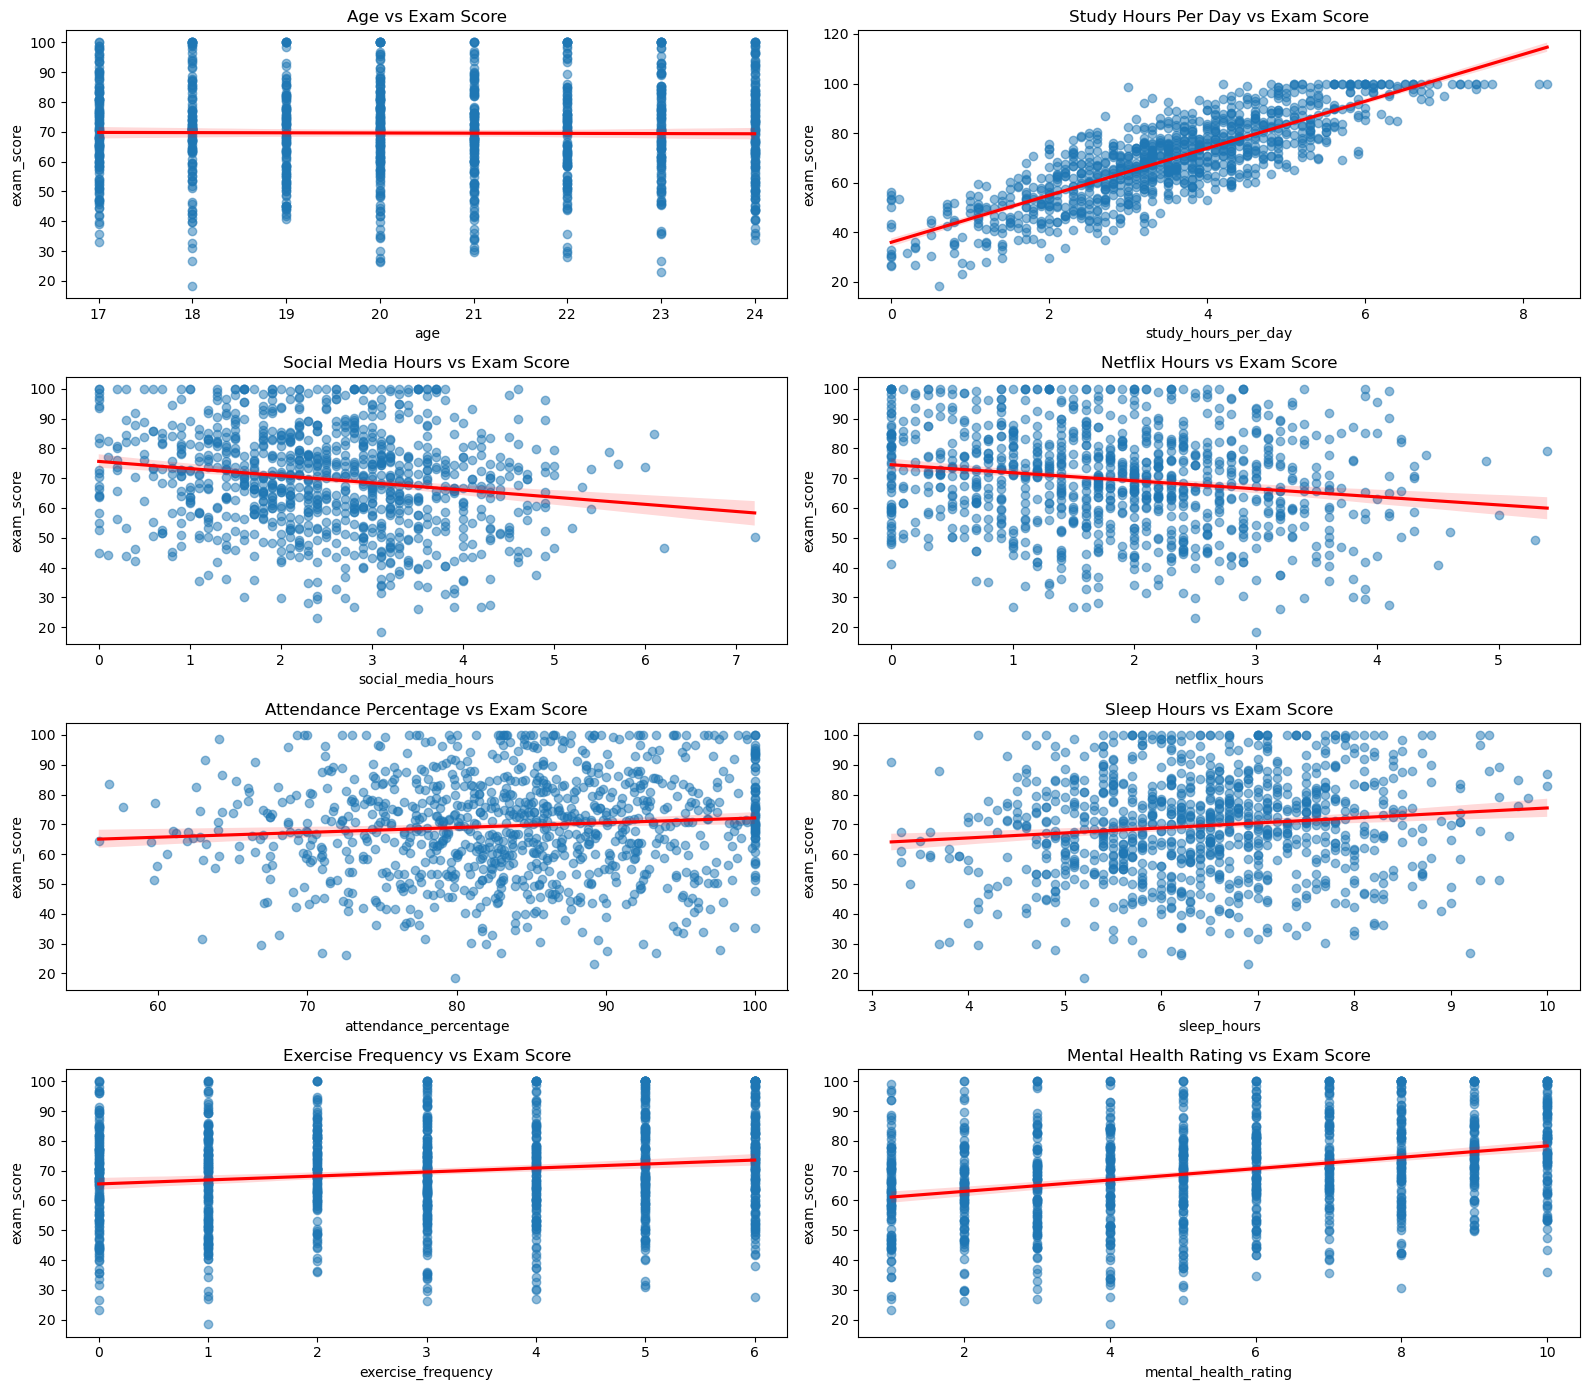

In [27]:
num_features = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]

fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(num_features):
    
    sns.regplot(
        data=df,
        x=col,
        y='exam_score',
        ax=axes[i],
        scatter_kws={'alpha':0.5},
        line_kws={'color':'red'}
    )
    
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Exam Score')
    axes[i].grid(False)

plt.tight_layout()
plt.show()

In [28]:
df['score_group'] = pd.cut(
    df['exam_score'],
    bins=[0, 50, 75, 100],
    labels=['Low', 'Medium', 'High'])

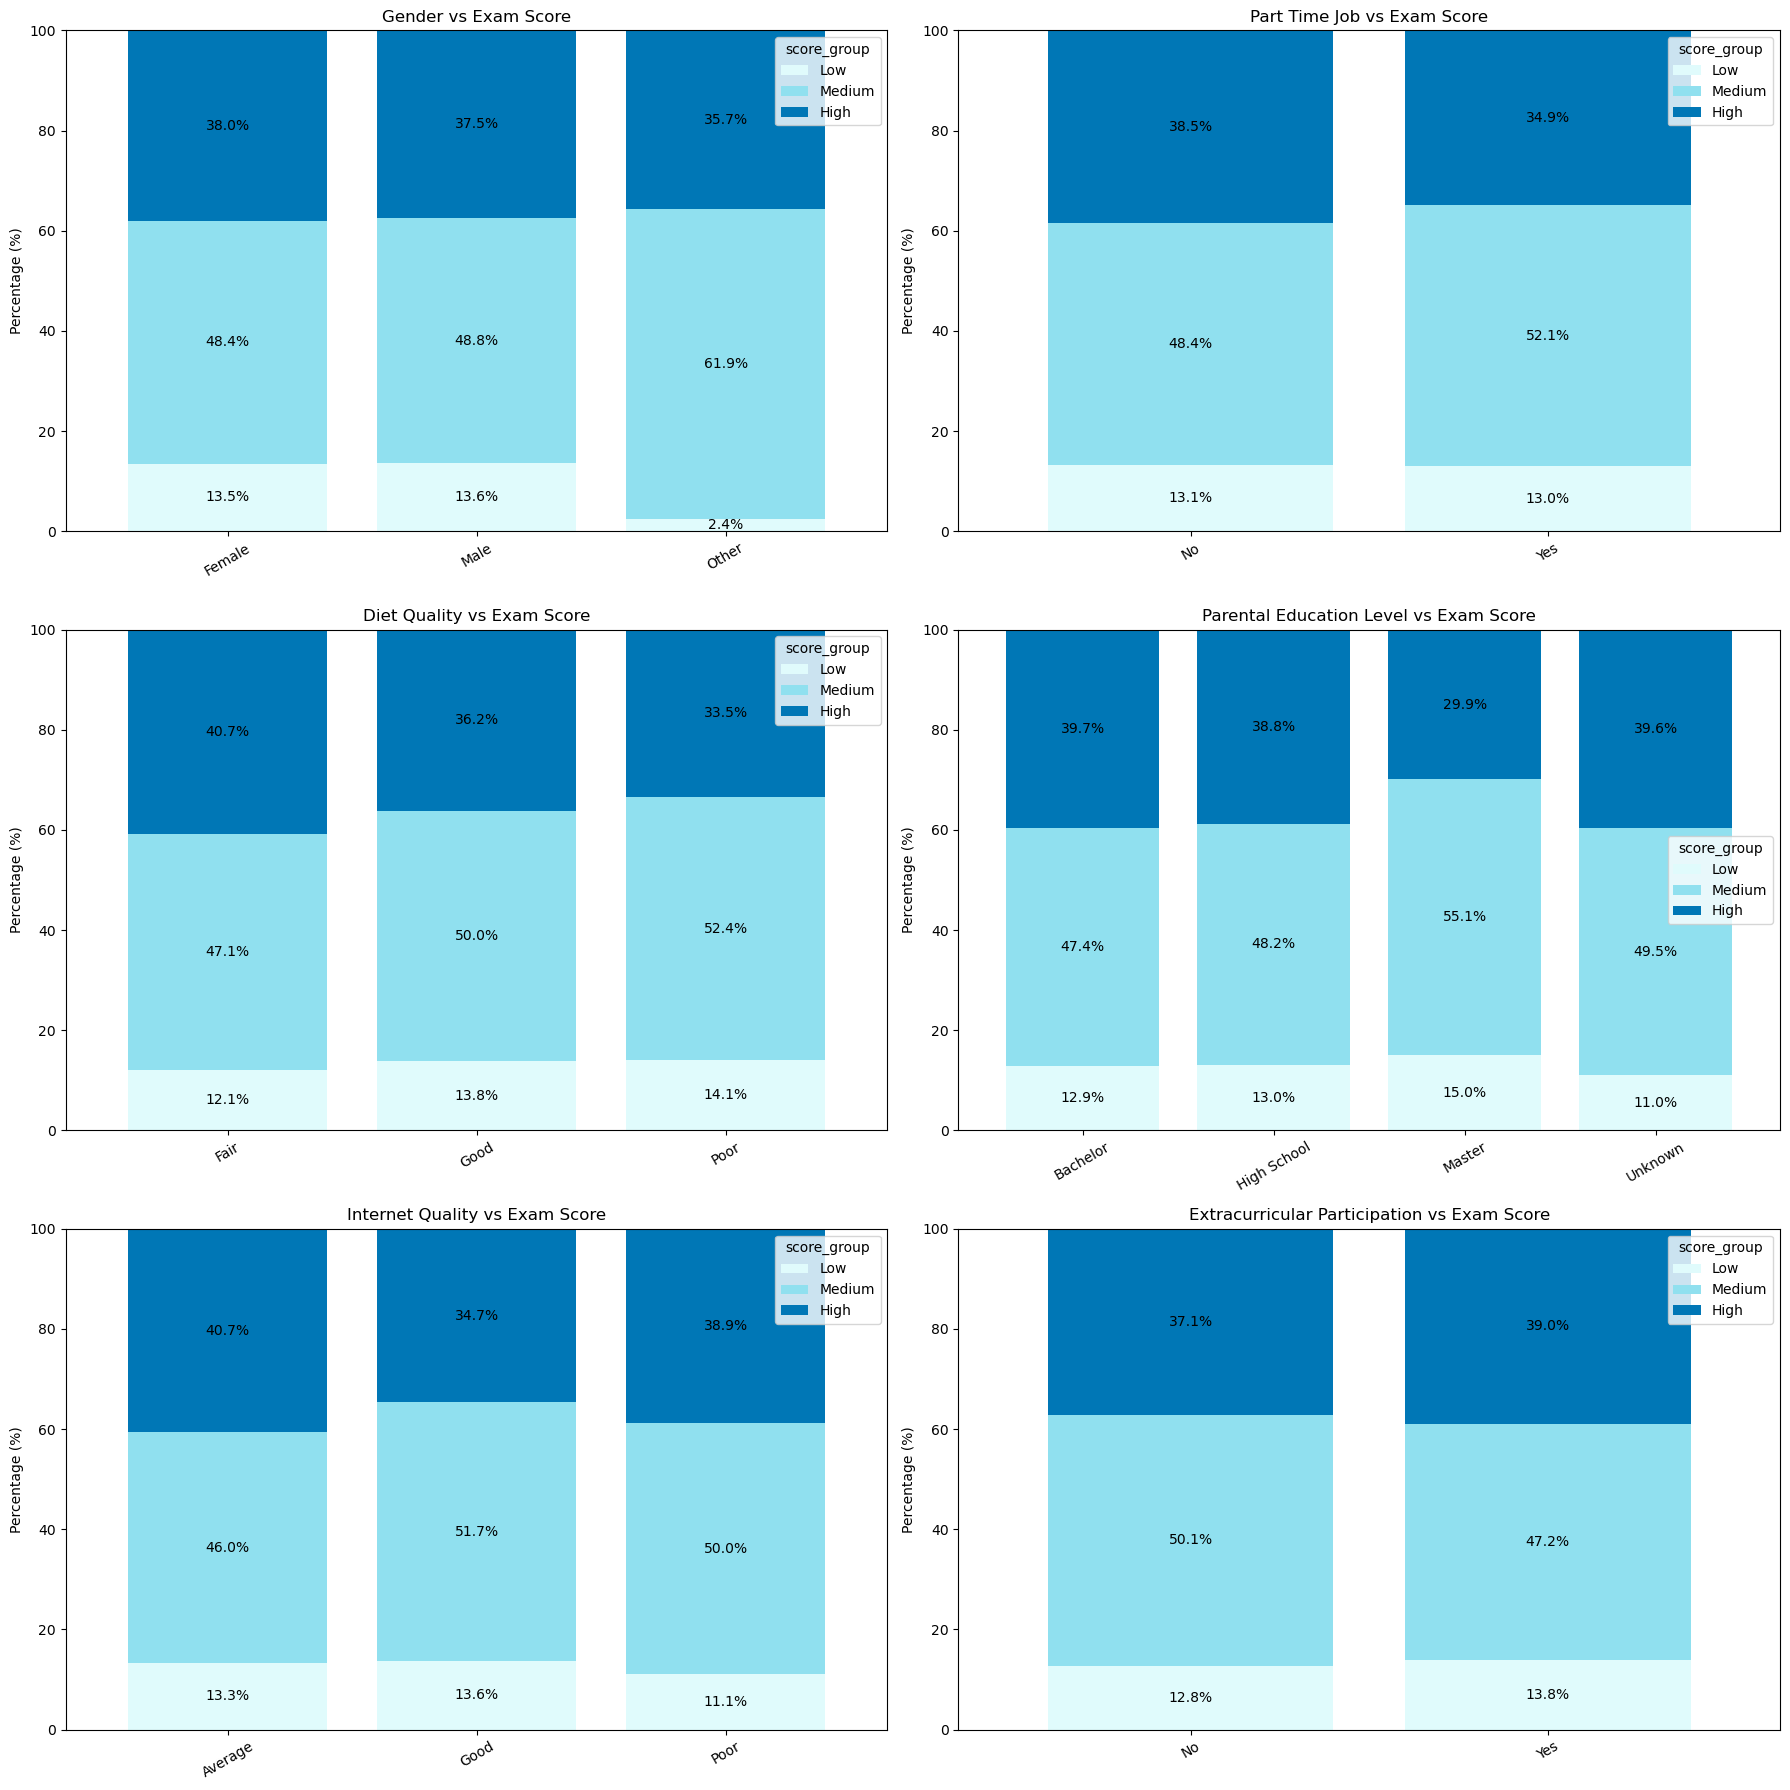

In [29]:
colors = ['#E0FBFC', '#90E0EF', '#0077B6']
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    ct = pd.crosstab(df[col], df['score_group'])
    ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100
    
    ct_percent.plot(
        kind='bar',
        stacked=True,
        ax=axes[i],
        color=colors,
        width=0.8
    )
    
    for p in axes[i].patches:
        height = p.get_height()
        if height > 0:  # avoid empty labels
            axes[i].text(
                p.get_x() + p.get_width()/2,
                p.get_y() + height/2,
                f'{height:.1f}%',
                ha='center',
                va='center',
                fontsize=10,
                color='black'
            )
    
    axes[i].set_title(f'{col.replace("_", " ").title()} vs Exam Score')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Percentage (%)')
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(False)

plt.tight_layout()
plt.show()

In [30]:
df_new = df.copy()

## Encoding Categorical Variables

In [31]:
df_new['gender'] = df_new['gender'].map({
    'Male': 1,
    'Female': 0,
    'Other': 2
})

df_new['part_time_job'] = df_new['part_time_job'].map({
    'Yes': 1,
    'No': 0
})

df_new['extracurricular_participation'] = df_new['extracurricular_participation'].map({
    'Yes': 1,
    'No': 0
})

df_new['diet_quality'] = df_new['diet_quality'].map({
    'Poor': 1,
    'Fair': 2,
    'Good': 3
})

df_new['internet_quality'] = df_new['internet_quality'].map({
    'Poor': 1,
    'Average': 2,
    'Good': 3
})

df_new['parental_education_level'] = df_new['parental_education_level'].map({
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'Unknown': 0   # treated as missing information category
})

In [32]:
df.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
score_group                      0
dtype: int64

In [33]:
df_new.isnull().sum()

student_id                       0
age                              0
gender                           0
study_hours_per_day              0
social_media_hours               0
netflix_hours                    0
part_time_job                    0
attendance_percentage            0
sleep_hours                      0
diet_quality                     0
exercise_frequency               0
parental_education_level         0
internet_quality                 0
mental_health_rating             0
extracurricular_participation    0
exam_score                       0
score_group                      0
dtype: int64

## Correlation Analysis

In [34]:
corr = df_new.corr(numeric_only=True)['exam_score'].sort_values(ascending=False)
print(corr)

exam_score                       1.000000
study_hours_per_day              0.825419
mental_health_rating             0.321523
exercise_frequency               0.160107
sleep_hours                      0.121683
attendance_percentage            0.089836
diet_quality                     0.015018
extracurricular_participation    0.000881
gender                          -0.002406
age                             -0.008907
parental_education_level        -0.021129
part_time_job                   -0.026608
internet_quality                -0.036298
social_media_hours              -0.166733
netflix_hours                   -0.171779
Name: exam_score, dtype: float64


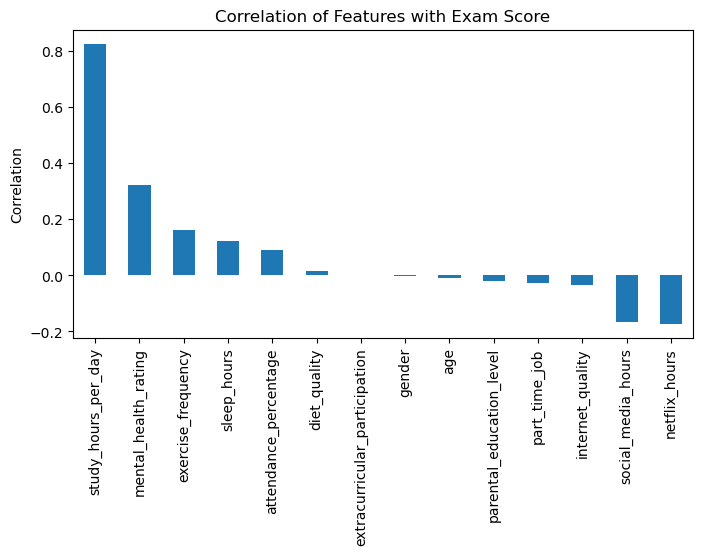

In [35]:
corr.drop('exam_score').plot(kind='bar', figsize=(8,4))

plt.title('Correlation of Features with Exam Score')
plt.ylabel('Correlation')
plt.grid(False)

plt.show()

In [36]:
corr_matrix = df_new.corr(numeric_only=True)
print(corr_matrix)

                                    age    gender  study_hours_per_day  \
age                            1.000000  0.032902             0.003971   
gender                         0.032902  1.000000            -0.016126   
study_hours_per_day            0.003971 -0.016126             1.000000   
social_media_hours            -0.009151  0.006555             0.020282   
netflix_hours                 -0.001174  0.033111            -0.031158   
part_time_job                 -0.011680  0.035515            -0.029133   
attendance_percentage         -0.026055 -0.021779             0.026264   
sleep_hours                    0.037482  0.018843            -0.027757   
diet_quality                   0.004117  0.004144             0.033377   
exercise_frequency            -0.003836  0.052808            -0.028701   
parental_education_level       0.003330 -0.021340            -0.012687   
internet_quality               0.007799 -0.033257             0.014459   
mental_health_rating          -0.04510

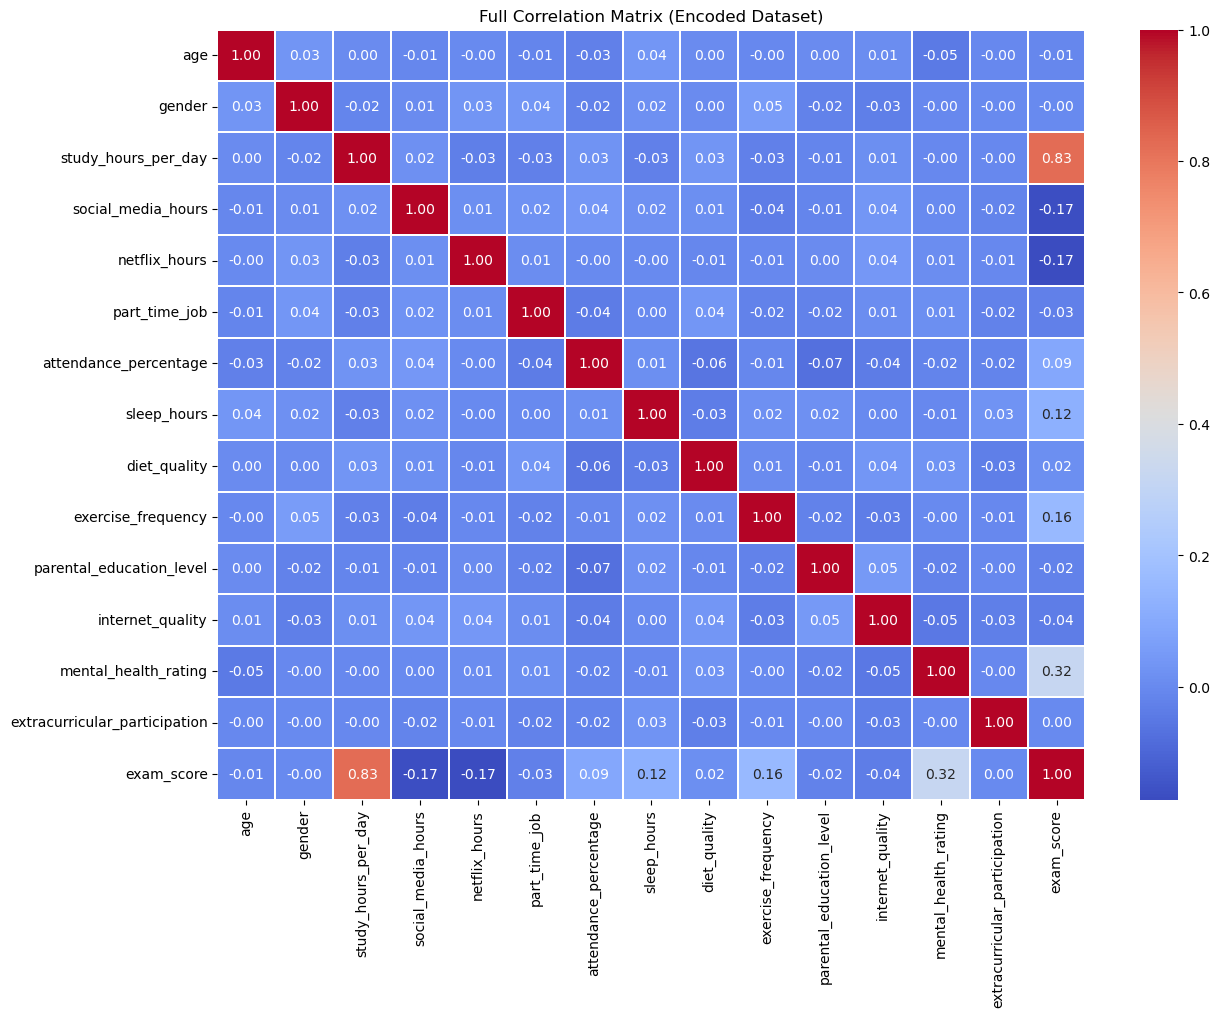

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.3
)

plt.title("Full Correlation Matrix (Encoded Dataset)")
plt.show()

## Model Building

In [38]:
X = df_new.drop(columns=['exam_score', 'student_id', 'score_group'])
y = df_new['exam_score']

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))

print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))

Train R²: 0.9013623006555946
Test R²: 0.8988414260742963
MAE: 4.144758410910476
RMSE: 5.093132794696932


In [43]:
import statsmodels.api as sm

X_const = sm.add_constant(X)
mlr_model = sm.OLS(y, X_const).fit()

print(mlr_model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     643.5
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:49:29   Log-Likelihood:                -3086.5
No. Observations:                1000   AIC:                             6203.
Df Residuals:                     985   BIC:                             6277.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

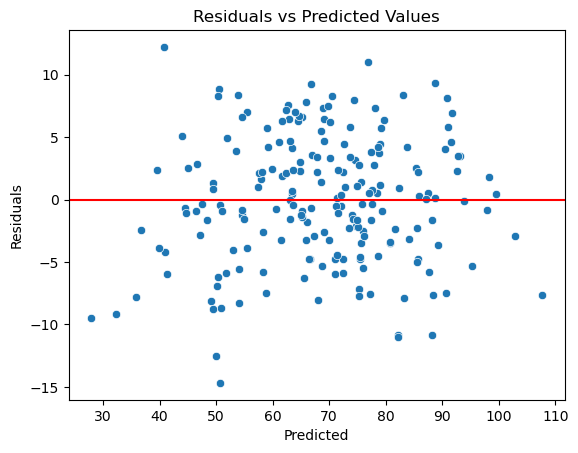

In [44]:
residuals = y_test - y_test_pred

sns.scatterplot(x=y_test_pred, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predicted Values")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.grid(False)
plt.show()

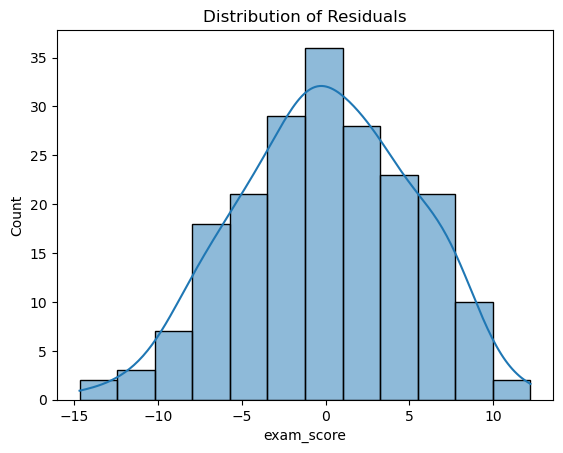

In [45]:
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.grid(False)
plt.show()

In [46]:
print("Mean residual:", np.mean(residuals))
print("Std residual:", np.std(residuals))

Mean residual: -0.04713136124682134
Std residual: 5.092914715485072


In [47]:
print(np.corrcoef(residuals[:-1], residuals[1:])[0,1])

-0.009379345944481447


In [48]:
def forward_selection_pvalues(X, y, significance_level=0.05):
    
    remaining_features = list(X.columns)
    selected_features = []

    while remaining_features:
        
        pvals = pd.Series(dtype=float)

        for feature in remaining_features:
            
            model_features = selected_features + [feature]
            
            X_model = sm.add_constant(X[model_features])
            
            model = sm.OLS(y, X_model).fit()

            pvals[feature] = model.pvalues[feature]

        min_p_value = pvals.min()

        if min_p_value < significance_level:
            
            best_feature = pvals.idxmin()

            selected_features.append(best_feature)
            remaining_features.remove(best_feature)

            print(f"Added: {best_feature} | p-value: {min_p_value:.6f}")

        else:
            break

    return selected_features

In [49]:
selected_features = forward_selection_pvalues(X, y)

print("\nSelected Features:")
print(selected_features)

Added: study_hours_per_day | p-value: 0.000000
Added: mental_health_rating | p-value: 0.000000
Added: social_media_hours | p-value: 0.000000
Added: exercise_frequency | p-value: 0.000000
Added: sleep_hours | p-value: 0.000000
Added: netflix_hours | p-value: 0.000000
Added: attendance_percentage | p-value: 0.000000

Selected Features:
['study_hours_per_day', 'mental_health_rating', 'social_media_hours', 'exercise_frequency', 'sleep_hours', 'netflix_hours', 'attendance_percentage']


In [50]:
X_final = sm.add_constant(X[selected_features])
final_model = sm.OLS(y, X_final).fit()

print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.901
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     1291.
Date:                Wed, 03 Jun 2026   Prob (F-statistic):               0.00
Time:                        15:50:02   Log-Likelihood:                -3088.4
No. Observations:                1000   AIC:                             6193.
Df Residuals:                     992   BIC:                             6232.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.15

In [51]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X[selected_features]
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_data.sort_values(by="VIF", ascending=False))

                 Feature        VIF
6  attendance_percentage  31.442121
4            sleep_hours  22.775424
0    study_hours_per_day   6.557519
2     social_media_hours   5.468930
1   mental_health_rating   4.489888
5          netflix_hours   3.776711
3     exercise_frequency   3.199372


In [52]:
from sklearn.linear_model import Ridge

In [63]:
ridge = Ridge(alpha=1.0)  
ridge.fit(X_train_scaled, y_train)

Ridge()

In [64]:
y_train_pred = ridge.predict(X_train_scaled)
y_test_pred = ridge.predict(X_test_scaled)

In [66]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": ridge.coef_
})

print(coef_df.sort_values(by="Coefficient", ascending=False))

                          Feature  Coefficient
2             study_hours_per_day    14.146485
12           mental_health_rating     5.564382
9              exercise_frequency     2.646301
7                     sleep_hours     2.423445
6           attendance_percentage     1.372275
5                   part_time_job     0.157496
0                             age     0.123027
1                          gender     0.120233
10       parental_education_level     0.077236
13  extracurricular_participation    -0.075746
11               internet_quality    -0.082579
8                    diet_quality    -0.235305
4                   netflix_hours    -2.525043
3              social_media_hours    -3.152937


In [67]:
mae = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))


In [68]:
print("\n===== MODEL SUMMARY =====")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Test R²:", r2_score(y_test, y_test_pred))
print("MAE:", mae)
print("RMSE:", rmse)


===== MODEL SUMMARY =====
Train R²: 0.9013608880498085
Test R²: 0.8987912065600143
MAE: 4.146536611292034
RMSE: 5.094396864111223


In [69]:
print("Intercept:", ridge.intercept_)

Intercept: 69.82737499999999


In [70]:
equation = f"Exam Score = {ridge.intercept_:.3f} "

for feature, coef in zip(X.columns, ridge.coef_):
    equation += f"+ ({coef:.3f} * {feature}) "

print(equation)

Exam Score = 69.827 + (0.123 * age) + (0.120 * gender) + (14.146 * study_hours_per_day) + (-3.153 * social_media_hours) + (-2.525 * netflix_hours) + (0.157 * part_time_job) + (1.372 * attendance_percentage) + (2.423 * sleep_hours) + (-0.235 * diet_quality) + (2.646 * exercise_frequency) + (0.077 * parental_education_level) + (-0.083 * internet_quality) + (5.564 * mental_health_rating) + (-0.076 * extracurricular_participation) 


Although outliers were present in several predictor variables, their impact was minimized by the use of Ridge Regression, which reduces sensitivity to extreme values